<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/Day-13-Ada_Boosting_Hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [4]:
np.random.seed(42)
x,y = make_circles(n_samples=500, factor=0.1,noise=0.35,random_state=42)

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

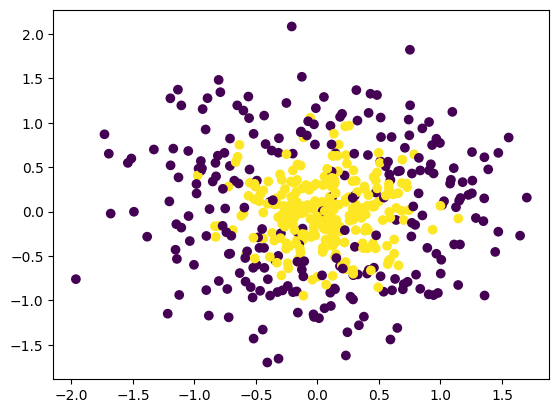

In [8]:
plt.scatter(x[:,0],x[:,1],c=y)

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc=AdaBoostClassifier()

np.mean(cross_val_score(abc,x,y,scoring='accuracy',cv=10))

np.float64(0.812)

In [16]:
abc.fit(x_train,y_train)

AdaBoostClassifier()

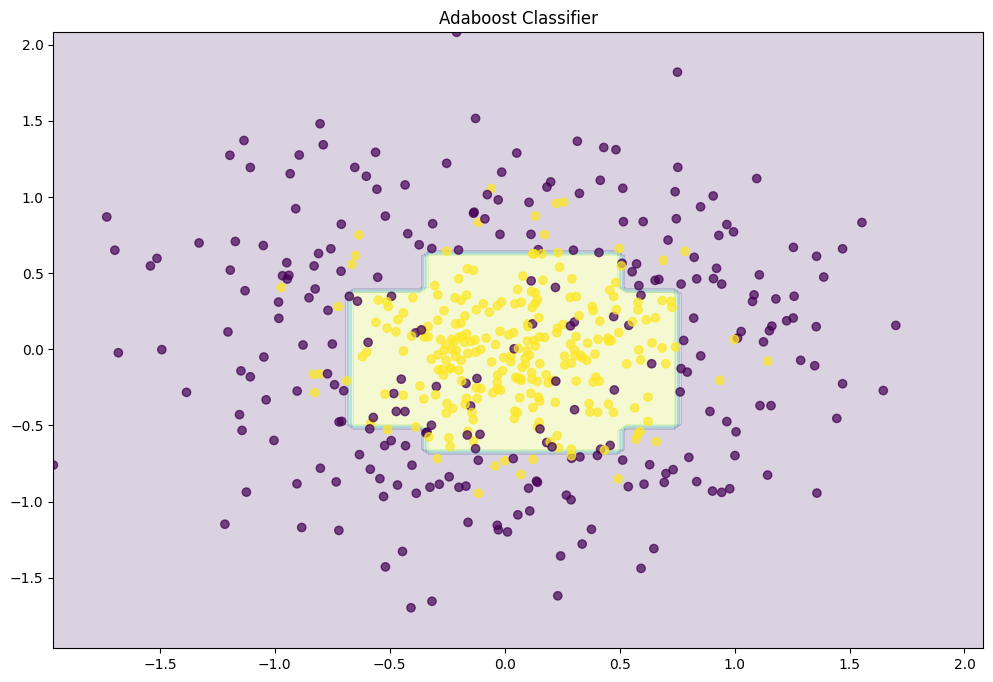

In [19]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(x.min(), x.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()

plot_decision_boundary(abc)


adding estimators and lr(learning rate)

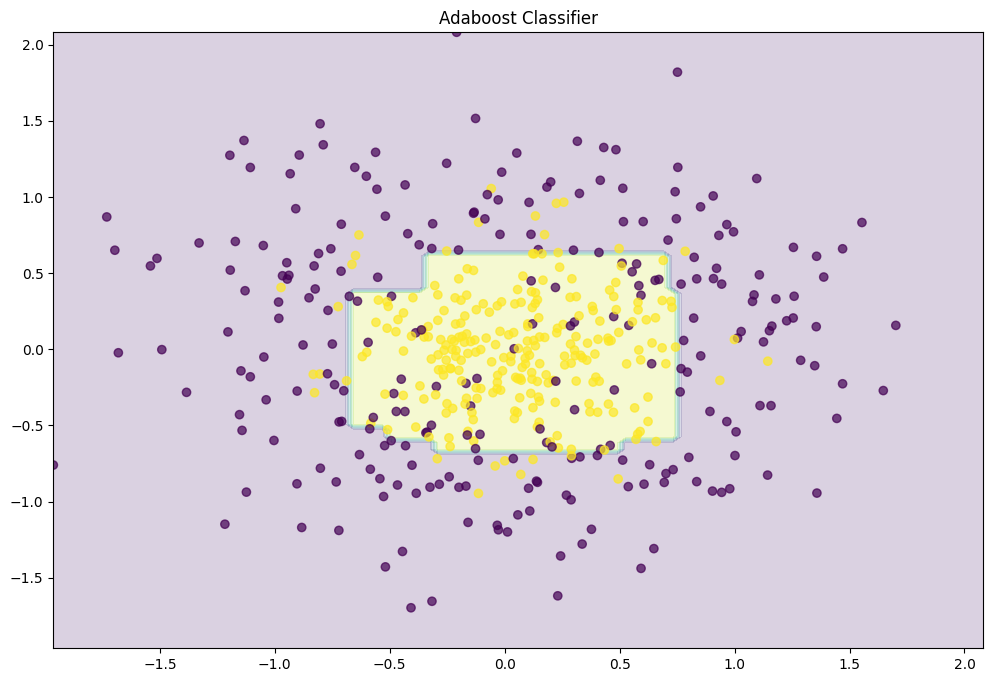

In [21]:
abc= AdaBoostClassifier(n_estimators=100,learning_rate=0.5)
abc.fit(x,y)
plot_decision_boundary(abc)

performing GridSearchCV to get best HyperParameter Tuning

In [27]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification


# Define the parameter grid
grid = {
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Initialize and execute the grid search
grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=grid,
    n_jobs=-1,
    cv=10,
    scoring='accuracy'
)

grid_search.fit(x, y)

# Summarize the best score and configuration (updated to use f-strings)
print(f"Best: {grid_search.best_score_:.6f} using {grid_search.best_params_}")

Best: 0.814000 using {'learning_rate': 1.0, 'n_estimators': 100}
